# A hybrid CAE + OC-SVM + MEWMA monitoring pipeline

This notebook explains and demonstrates the monitoring methodology developed in this
project. A convolutional autoencoder (CAE) learns a compact representation of short
multivariate time windows, a one-class support vector machine (OC-SVM) turns that
representation into a single anomaly score, and a multivariate EWMA (MEWMA) control
chart accumulates evidence over time until it signals.

The verified implementation lives in `pipeline.py`, a single flat module organised in
numbered sections (§0 constants through §10 Phase II evaluation). **This notebook does
not re-implement any of it.** It imports `pipeline.py` and calls its public functions,
so everything shown here is the same code that produced the reported results.

What this notebook deliberately does *not* do:

* it does not train the autoencoder or fit the one-class SVM — both are loaded frozen;
* it does not re-estimate in-control moments or re-search control limits;
* it does not run the full Phase II evaluation, which is expensive.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np

import pipeline
from thesis_plots import NEUTRAL, apply_style, save_figure

apply_style()

print("pipeline.py loaded from:", pipeline.PROJECT_ROOT)

pipeline.py loaded from: /home/stephen/projects/pipeline-thesis-independent


## 1. Methodology overview

The experiment monitors a simulated multivariate process whose faults are not visible
as a simple mean shift in the observed channels. The chain from raw process to alarm is:

```
latent VAR(1) process          z_t = mu_t + Phi (z_{t-1} - mu_{t-1}) + eta_t
        |
nonlinear observation model    x_t = W2 tanh(W1 z_t + b1) + b2 + eps_t      (4 channels)
        |
sliding windows                length L = 32, stride 1, right-aligned
        |
frozen CAE                     h_t = encoder(window_t)            (8 latent features)
                               SPE_t = || window_t - decoder(h_t) ||^2   (summed)
        |
frozen OC-SVM                  s_t = -decision_function(h_t)      (larger = worse)
        |
monitoring vector              y_t = [ s_t , log SPE_t ]
        |
MEWMA                          m_j = lambda y_j + (1 - lambda) m_{j-1}
        |
T-squared                      T2_j = (m_j - mu)' [c_j Sigma]^-1 (m_j - mu)
        |
signal / run length            first j with T2_j > h
```

The two monitoring components answer different questions. The OC-SVM score asks
whether the *encoded* window looks like the in-control latent cloud; the reconstruction
error asks whether the autoencoder could represent the window at all. A fault that
moves the process inside the learned latent region but breaks its temporal shape shows
up in the second component and not the first, which is the motivation for combining them.

### Dataset roles

Five independently simulated datasets keep fitting and evaluation strictly separate.
The roles are a scientific invariant, not a convention: no dataset is ever used for two
purposes.

| Data | Role |
|---|---|
| **D1** | representation learning — the CAE is trained on it (and its preprocessing statistics fitted on its training split) |
| **D2** | one-class detection — the OC-SVM is fitted on the CAE features of this series |
| **D3** | in-control calibration — pooled monitoring moments and the control limits are estimated here |
| **D4** | independent in-control validation — the honest in-control ARL is measured here |
| **D5** | out-of-control evaluation — fifteen sustained-shift scenarios |

D1–D3 are Phase I (fitting and calibration). D4 and D5 are Phase II: every artifact is
frozen before they are touched, and nothing is refitted, rescaled or retuned on them.

## 2. Frozen design constants

Every scientific constant of the experiment is stated once, explicitly, in `pipeline.py`
§0. The table below is read from the module itself rather than transcribed, so it cannot
drift away from the code that runs.

In [2]:
def constants_table(rows):
    """Format (label, attribute) pairs by reading pipeline.py directly."""
    width = max(len(label) for label, _ in rows)
    for label, attribute in rows:
        value = getattr(pipeline, attribute)
        if isinstance(value, np.ndarray):
            value = f"array, shape {value.shape}"
        print(f"{label:<{width}}  {value}")


constants_table([
    ("master seed",                 "SEED"),
    ("latent process dimension",    "LATENT_DIM"),
    ("observed channels",           "OBS_DIM"),
    ("burn-in length",              "BURN_IN"),
    ("window length L",             "WINDOW_LENGTH"),
    ("window stride",               "WINDOW_STRIDE"),
    ("first monitorable time",      "FIRST_REPRESENTED_TIME_INDEX"),
    ("D1 training fraction",        "TRAIN_FRACTION"),
    ("CAE bottleneck dimension",    "CAE_LATENT_DIM"),
    ("CAE encoder channels",        "ENCODER_CHANNELS"),
    ("OC-SVM kernel",               "KERNEL"),
    ("OC-SVM nu",                   "NU"),
    ("OC-SVM gamma rule",           "GAMMA_RULE"),
    ("monitoring components",       "MONITORING_COMPONENTS"),
    ("primary smoothing lambda",    "PRIMARY_LAMBDA"),
    ("sensitivity lambdas",         "HYBRID_SENSITIVITY_LAMBDAS"),
    ("benchmark lambda",            "BENCHMARK_LAMBDA"),
    ("target in-control ARL",       "TARGET_ARL0"),
    ("calibration horizon",         "CALIBRATION_HORIZON"),
])

master seed               795
latent process dimension  8
observed channels         4
burn-in length            500
window length L           32
window stride             1
first monitorable time    32
D1 training fraction      0.8
CAE bottleneck dimension  8
CAE encoder channels      (8, 16)
OC-SVM kernel             rbf
OC-SVM nu                 0.03
OC-SVM gamma rule         inverse_median_pairwise_squared_distance
monitoring components     ('ocsvm_score', 'log_spe')
primary smoothing lambda  0.05
sensitivity lambdas       (0.1, 0.2)
benchmark lambda          0.05
target in-control ARL     370
calibration horizon       2969


In [3]:
print("D1 length                  ", pipeline.D1_LENGTH)
print("D2 length                  ", pipeline.D2_LENGTH)
print("D3 replications x horizon  ", pipeline.D3_REPLICATIONS, "x", pipeline.D3_HORIZON)
print("D4 replications x horizon  ", pipeline.D4_REPLICATIONS, "x", pipeline.D4_HORIZON)
print("D5 replications x horizon  ", pipeline.D5_REPLICATIONS, "x", pipeline.D5_HORIZON,
      f"per scenario, {pipeline.SHIFT_GRID.size} scenarios")
print("shift magnitudes           ", pipeline.SHIFT_GRID)
print("fault direction            ", np.round(pipeline.FAULT_DIRECTION, 4))

D1 length                   2000
D2 length                   2000
D3 replications x horizon   300 x 3000
D4 replications x horizon   500 x 3000
D5 replications x horizon   500 x 3000 per scenario, 15 scenarios
shift magnitudes            [0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3. ]
fault direction             [0.7071 0.7071 0.     0.     0.     0.     0.     0.    ]


## 3. Synthetic data

The process is a stable latent VAR(1) observed through a fixed nonlinear map with
additive measurement noise. Each trajectory has its own seeded random stream and its own
burn-in, so a series generated on its own is identical to the same series taken from a
full bank — the simulation is deterministic given the seed.

A fault is a sustained shift of the *latent* mean along a fixed direction. Because the
observation map is nonlinear, that shift reaches the four observed channels in a form
that is not a clean shift of their means, which is exactly what makes a conventional
chart on the raw channels a demanding benchmark.

Here we generate only the two light single-series datasets, D1 and D2.

In [4]:
d1 = pipeline.generate_d1()
d2 = pipeline.generate_d2()

print("D1 observations:", d1.shape, d1.dtype)
print("D2 observations:", d2.shape, d2.dtype)
print("\nFirst three rows of D1 (four observed channels):")
print(np.array2string(d1[:3], precision=4, suppress_small=True))

D1 observations: (2000, 4) float64
D2 observations: (2000, 4) float64

First three rows of D1 (four observed channels):
[[-0.8749 -0.8491 -0.6406 -0.547 ]
 [-1.1867 -0.2937 -0.5248 -0.1442]
 [-0.297  -0.3555 -0.1979 -0.5075]]


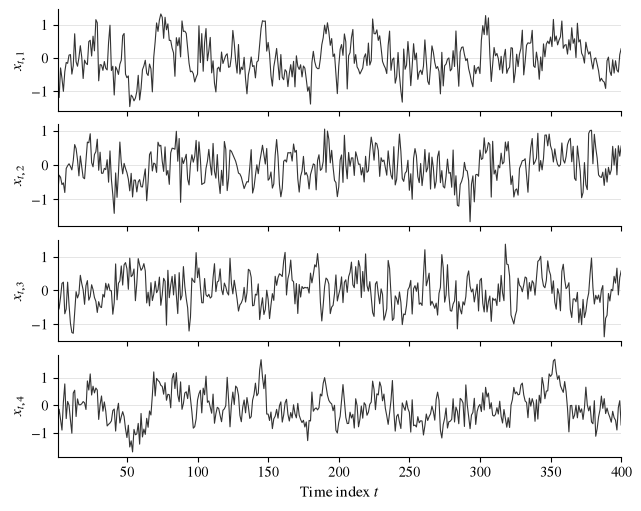

In [5]:
# First 400 D1 observations of each of the four observed channels.
fig, axes = plt.subplots(4, 1, figsize=(6.3, 5.0), sharex=True, layout="constrained")
for channel, ax in enumerate(axes):
    ax.plot(np.arange(1, 401), d1[:400, channel], color=NEUTRAL, linewidth=0.8)
    ax.set_ylabel(f"$x_{{t,{channel + 1}}}$")
axes[-1].set_xlim(1, 400)
axes[-1].set_xlabel("Time index $t$")
fig.align_ylabels(axes)
save_figure(fig, "methodology_d1_observed_channels")
plt.show()

## 4. Preprocessing and windowing

The order of operations here is scientific rather than incidental:

```
split raw D1  ->  fit statistics on the training rows only  ->  standardize  ->  window
```

The split is chronological: the first 80% of D1 trains the autoencoder, the last 20%
validates it. Splitting *before* windowing is what keeps the validation segment out of
the fitted statistics — a window straddling the boundary would carry training rows into
validation. The 31 straddling windows are simply never formed.

Per-channel standardization uses the population convention (`ddof = 0`) and is fitted on
the D1 training rows alone. Nothing downstream ever refits it; D2–D5 are standardized
with these same frozen numbers.

In [6]:
train_rows, validation_rows = pipeline.split_d1(d1)
mean, scale = pipeline.fit_preprocessing(train_rows)

print("D1 training rows  :", train_rows.shape)
print("D1 validation rows:", validation_rows.shape)
print("\nfitted per-channel mean :", np.round(mean, 6))
print("fitted per-channel scale:", np.round(scale, 6))

D1 training rows  : (1600, 4)
D1 validation rows: (400, 4)

fitted per-channel mean : [-0.01351  -0.003201 -0.01417  -0.021406]
fitted per-channel scale: [0.584534 0.492404 0.505249 0.577733]


A window is `L = 32` consecutive rows, taken with stride 1 and labelled by its **last**
row. The first window therefore covers rows 1–32 and is labelled `t = 32`: no monitoring
decision is possible before time 32, for any chart.

The windows are handed to the CAE in channels-first orientation, `(windows, channels,
time)`. A 1D convolution slides its kernel along the *last* axis, so putting time last
and the four measured channels in the channel axis is what makes the convolution a
temporal filter that sees all four channels at once. A `(windows, time, channels)`
layout would convolve across channels instead, which has no physical meaning here.

In [7]:
train_windows = pipeline.window_series(pipeline.apply_preprocessing(train_rows, mean, scale))
validation_windows = pipeline.window_series(
    pipeline.apply_preprocessing(validation_rows, mean, scale)
)

print("training windows  :", train_windows.shape, " (windows, channels, time)")
print("validation windows:", validation_windows.shape)
print("\n1600 + 400 raw rows give", train_windows.shape[0], "+", validation_windows.shape[0],
      "=", train_windows.shape[0] + validation_windows.shape[0], "windows,")
print("rather than the", pipeline.D1_LENGTH - pipeline.WINDOW_LENGTH + 1,
      "an unsplit series would give: the 31 windows straddling the split are not formed.")

training windows  : (1569, 4, 32)  (windows, channels, time)
validation windows: (369, 4, 32)

1600 + 400 raw rows give 1569 + 369 = 1938 windows,
rather than the 1969 an unsplit series would give: the 31 windows straddling the split are not formed.


## 5. The frozen convolutional autoencoder

The representation learner is a small 1D convolutional autoencoder. A window enters as
`(4, 32)`; two stride-2 convolutions halve the time axis twice, giving `16 x 8 = 128`
features that a linear layer projects down to the 8-dimensional bottleneck `h_t`. The
decoder mirrors that exactly and returns to `(4, 32)`.

The network was trained once, on the D1 training windows only, with early stopping on
the validation windows, and its weights were frozen at the best-validation epoch.
Everything downstream reads those frozen weights. `pipeline.py` retains
`train_autoencoder()` so the training procedure is readable and rerunnable, but the
default reproduction path — and the one used here — is `load_autoencoder()`.

In [8]:
autoencoder = pipeline.load_autoencoder()
print(autoencoder)
print("\ntrainable parameters:",
      sum(p.numel() for p in autoencoder.parameters() if p.requires_grad))

ConvAutoencoder1d(
  (encoder_conv): Sequential(
    (0): Conv1d(4, 8, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(8, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_linear): Linear(in_features=128, out_features=8, bias=True)
  (decoder_linear): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
  )
  (decoder_conv): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(16, 8))
    (1): ConvTranspose1d(16, 8, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (2): ReLU()
    (3): ConvTranspose1d(8, 4, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
  )
)

trainable parameters: 3180


Two quantities come out of one inference pass over the same windows:

* the **latent feature** `h_t`, the 8-dimensional code the encoder assigns to the window;
* the **squared prediction error** `SPE_t`, the squared reconstruction residual **summed**
  over all `4 x 32 = 128` values of the window.

SPE is a sum, not a mean, and it is not the mean-squared-error training loss — the two
coexist in the pipeline and are different quantities. It is floored at a small epsilon
before the logarithm so that a vanishing reconstruction error cannot produce `-inf`.

We run the frozen network over D2, the in-control series the one-class detector was
fitted on.

In [9]:
features, spe_values = pipeline.infer_series(autoencoder, d2, mean, scale)
log_spe_values = pipeline.log_spe(spe_values)

print("latent features h_t:", features.shape, features.dtype)
print("SPE_t              :", spe_values.shape, spe_values.dtype)
print("\nh_t for the first window:", np.round(features[0], 4))
print("SPE for the first window:", round(float(spe_values[0]), 6),
      " log SPE:", round(float(log_spe_values[0]), 6))
print("\nSPE summary over D2: min %.4f  median %.4f  max %.4f"
      % (spe_values.min(), np.median(spe_values), spe_values.max()))

latent features h_t: (1969, 8) float32
SPE_t              : (1969,) float64

h_t for the first window: [ 4.0593  2.1591 -1.447  -1.7837  1.0676 -0.3527 -3.3287  1.248 ]
SPE for the first window: 69.508922  log SPE: 4.241455

SPE summary over D2: min 49.1201  median 86.2495  max 139.6032


## 6. The frozen one-class SVM

The one-class SVM was fitted on the CAE features of D2 with an RBF kernel. No feature
scaling sits between the bottleneck and the detector: the OC-SVM consumes `h_t` directly,
cast from the network's `float32` to `float64` at that boundary.

Its frozen state is four objects — the support vectors, their dual coefficients, the
offset `rho`, and the kernel width `gamma`. The score is evaluated from them directly:

$$ s(x) \;=\; \rho \;-\; \sum_j \alpha_j \exp\!\left(-\gamma \lVert x - x_j \rVert^2\right) $$

which is exactly `-decision_function(x)`. The sign convention matters: **larger `s_t`
means more abnormal**. `gamma` was resolved once during fitting by the inverse-median-
pairwise-squared-distance rule and persisted; re-evaluating that rule on any monitored
data would be a refit, so it is loaded, never recomputed.

In [10]:
ocsvm = pipeline.load_ocsvm()

print("gamma            :", ocsvm.gamma)
print("rho              :", ocsvm.rho)
print("support vectors  :", ocsvm.support_vectors.shape[0],
      f"of {features.shape[0]} fitting windows",
      f"({100 * ocsvm.support_vectors.shape[0] / features.shape[0]:.1f}%)")
print("nu (contracted)  :", pipeline.NU)

scores = pipeline.ocsvm_score(ocsvm, pipeline.to_ocsvm_input(features))
print("\ns_t:", scores.shape, scores.dtype)
print("s_t summary over D2: min %.4f  median %.4f  max %.4f"
      % (scores.min(), np.median(scores), scores.max()))

gamma            : 0.030522830729177747
rho              : 8.846560927608301
support vectors  : 78 of 1969 fitting windows (4.0%)
nu (contracted)  : 0.03

s_t: (1969,) float64
s_t summary over D2: min -8.0334  median -3.6983  max 1.6678


## 7. The hybrid monitoring vector

The chart watches

$$ y_t \;=\; \bigl[\, s_t,\; \log \mathrm{SPE}_t \,\bigr]^{\mathsf T} $$

Both components come out of a single inference call over the same windows. That is not
an optimisation: reading them from one result is what makes it structurally impossible
for `s_t` and `log SPE_t` to be misaligned by an index. The column order is frozen —
column 0 is the score, column 1 is the log SPE. Nothing downstream carries a label, so a
transposed pair would silently reinterpret every calibrated control limit rather than fail.

In [11]:
frozen = pipeline.load_frozen()
y = pipeline.monitoring_series(frozen, d2)

print("monitoring vectors:", y.shape, y.dtype,
      f"  ({pipeline.D2_LENGTH} rows - {pipeline.WINDOW_LENGTH - 1})")
print("\n   t        s_t    log SPE_t")
for row, (score, log_spe_value) in enumerate(y[:6]):
    print(f"{row + pipeline.WINDOW_LENGTH:>4}  {score:9.4f}  {log_spe_value:9.4f}")

monitoring vectors: (1969, 2) float64   (2000 rows - 31)

   t        s_t    log SPE_t
  32     0.8852     4.2415
  33    -0.4842     4.3751
  34     0.0680     4.2270
  35    -0.0002     4.3149
  36     0.1568     4.3566
  37     0.2521     4.3879


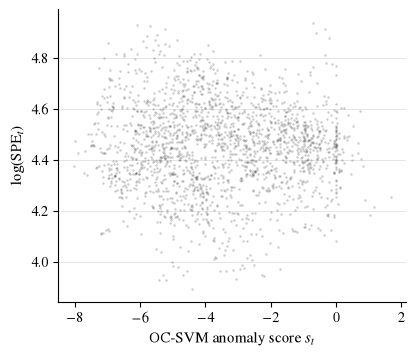

In [12]:
# In-control D2 monitoring vectors. No control boundary is drawn: the MEWMA chart acts on
# the smoothed state m_j, not on these raw points.
fig, ax = plt.subplots(figsize=(4.5, 3.8))
ax.scatter(y[:, 0], y[:, 1], s=3, alpha=0.25, color=NEUTRAL, linewidths=0)
ax.set_xlabel("OC-SVM anomaly score $s_t$")
ax.set_ylabel(r"$\log(\mathrm{SPE}_t)$")
save_figure(fig, "methodology_d2_monitoring_vector")
plt.show()

The in-control marginal distributions of the two components on D2 show the scale and shape
of each quantity entering $y_t = [s_t, \log(\mathrm{SPE}_t)]^{\mathsf T}$. They describe the
monitoring inputs; they are not a measure of detection performance.

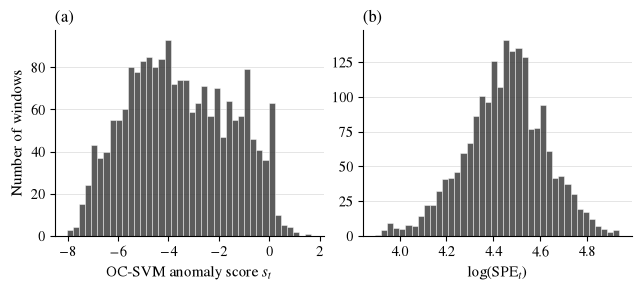

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(6.3, 2.8), layout="constrained")
components = [
    (scores, "OC-SVM anomaly score $s_t$"),
    (log_spe_values, r"$\log(\mathrm{SPE}_t)$"),
]
for ax, tag, (values, xlabel) in zip(axes, "ab", components):
    ax.hist(values, bins=40, color=NEUTRAL, alpha=0.8, edgecolor="white", linewidth=0.4)
    ax.set_xlabel(xlabel)
    ax.set_title(f"({tag})", loc="left")
axes[0].set_ylabel("Number of windows")
save_figure(fig, "methodology_d2_component_distributions")
plt.show()

## 8. MEWMA setup

Each replication starts at the in-control centre and exponentially smooths its own
monitoring vectors,

$$ m_0 = \hat\mu, \qquad m_j = \lambda\, y_j + (1-\lambda)\, m_{j-1}, $$

and the chart statistic is the distance of that state from the centre, standardised by
the state's own nominal covariance,

$$ T^2_j = (m_j - \hat\mu)^{\mathsf T}\bigl[c_j \hat\Sigma\bigr]^{-1}(m_j - \hat\mu),
\qquad c_j = \frac{\lambda}{2-\lambda}\Bigl[1 - (1-\lambda)^{2j}\Bigr]. $$

`c_j` is the **finite-start** factor, not its asymptotic limit `lambda / (2 - lambda)`.
The distinction is not cosmetic: at `j = 1` the exact factor is `lambda^2`, which for
`lambda = 0.05` is an order of magnitude smaller than the limit. Using the limit would
understate the divisor at exactly the indices where the state has barely moved off the
centre, and the resulting burst of early false alarms would dominate the in-control ARL.

The signal rule is strictly `T2 > h`, and a replication that never signals is censored at
the horizon and flagged as such rather than inferred from its run length.

The in-control mean and covariance are pooled over D3 and frozen; Phase II loads them
rather than re-estimating, because the calibration bank is closed to it.

In [14]:
hybrid_moments, benchmark_moments = pipeline.load_moments()

print("hybrid centre  mu_y:", np.round(hybrid_moments.mean, 6))
print("hybrid  Sigma_y:\n", np.round(hybrid_moments.covariance, 6))
print("\nbenchmark centre mu_x:", np.round(benchmark_moments.mean, 6))
print("benchmark Sigma_x shape:", benchmark_moments.covariance.shape)

hybrid centre  mu_y: [-3.709532  4.440224]
hybrid  Sigma_y:
 [[ 4.903646 -0.054034]
 [-0.054034  0.027454]]

benchmark centre mu_x: [ 0.002514  0.00049  -0.001279 -0.000679]
benchmark Sigma_x shape: (4, 4)


In [15]:
lambda_value = pipeline.PRIMARY_LAMBDA
j = np.arange(1, 9)
exact = pipeline.finite_start_factors(8, lambda_value)
asymptotic = lambda_value / (2.0 - lambda_value)

print(f"lambda = {lambda_value}, asymptotic factor = {asymptotic:.6f}\n")
print("   j     exact c_j   asymptotic / exact")
for index, factor in zip(j, exact):
    print(f"{index:>4}  {factor:12.8f}  {asymptotic / factor:15.1f}x")

lambda = 0.05, asymptotic factor = 0.025641

   j     exact c_j   asymptotic / exact
   1    0.00250000             10.3x
   2    0.00475625              5.4x
   3    0.00679252              3.8x
   4    0.00863025              3.0x
   5    0.01028880              2.5x
   6    0.01178564              2.2x
   7    0.01313654              2.0x
   8    0.01435573              1.8x


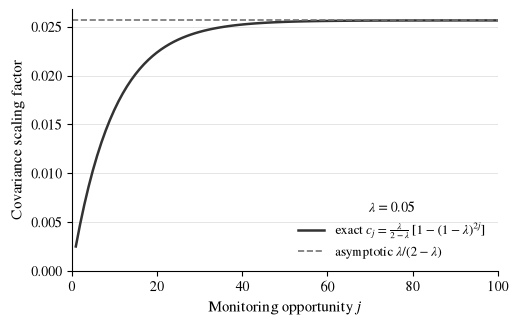

In [16]:
# Exact finite-start factor converging to its asymptotic value over the first 100 opportunities.
n_opportunities = 100
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.plot(
    np.arange(1, n_opportunities + 1),
    pipeline.finite_start_factors(n_opportunities, lambda_value),
    color=NEUTRAL, linewidth=1.8,
    label=r"exact $c_j = \frac{\lambda}{2-\lambda}\,[1-(1-\lambda)^{2j}]$",
)
ax.axhline(asymptotic, color="0.45", linestyle="--", linewidth=1.2,
           label=r"asymptotic $\lambda/(2-\lambda)$")
ax.set_xlim(0, n_opportunities)
ax.set_ylim(bottom=0)
ax.set_xlabel("Monitoring opportunity $j$")
ax.set_ylabel("Covariance scaling factor")
ax.legend(loc="lower right", title=rf"$\lambda = {lambda_value}$")
save_figure(fig, "methodology_finite_start_factor")
plt.show()

### The four pre-registered charts

Four charts were fixed in advance, giving six calibrated limits:

* **H** — the primary hybrid chart, using both monitoring components, at three smoothing
  constants (0.05, 0.10, 0.20);
* **S** — an ablation using the OC-SVM score only;
* **R** — an ablation using the log SPE only;
* **M** — a standalone conventional MEWMA on the four raw observed channels, the
  classical benchmark. It loads no autoencoder and no SVM quantity.

M needs care in one respect. It can start at `t = 1`, whereas the hybrid charts cannot
produce a statistic before `t = 32`. To put them on the same footing, M absorbs the
first 31 raw observations as a **silent warm-up**: those updates move its MEWMA state but
raise no alarm and enter no run length, so M's first reported decision is its 32nd update
and its finite-start factor there is `c_32`, not `lambda^2`.

Each limit was calibrated on D3 alone, as the smallest attained statistic whose empirical
in-control ARL reaches the target of 370. The achieved ARL generally overshoots the target
slightly; that overshoot is reported, never tuned away.

In [17]:
limits = json.loads((pipeline.PROJECT_ROOT / "models" / "control_limits.json").read_text())
by_key = {pipeline.limit_key(entry["chart_id"], entry["lambda"]): entry for entry in limits}

header = f"{'chart':<6}{'role':<20}{'source':<28}{'dim':>4}{'lambda':>8}{'h*':>11}{'ARL0':>10}{'censored':>10}"
print(header)
print("-" * len(header))
for chart_id, lam in pipeline.chart_plan():
    entry = by_key[pipeline.limit_key(chart_id, lam)]
    print(f"{entry['chart_id']:<6}{entry['role']:<20}{entry['source']:<28}"
          f"{entry['dimension']:>4}{entry['lambda']:>8}{entry['h_star']:>11.4f}"
          f"{entry['achieved_arl0']:>10.2f}{entry['censor_count']:>10}")

print("\ntarget in-control ARL:", pipeline.TARGET_ARL0,
      "| signal rule:", limits[0]["signal_rule"],
      "| calibration horizon:", pipeline.CALIBRATION_HORIZON)

chart role                source                       dim  lambda         h*      ARL0  censored
-------------------------------------------------------------------------------------------------
H     primary             hybrid_monitoring_vector       2    0.05   111.0830    371.04         0
H     hybrid_sensitivity  hybrid_monitoring_vector       2     0.1    83.5878    370.54         0
H     hybrid_sensitivity  hybrid_monitoring_vector       2     0.2    51.4306    372.44         1
S     ablation            hybrid_monitoring_vector       1    0.05    66.0452    370.63         0
R     ablation            hybrid_monitoring_vector       1    0.05    71.0284    371.34         0
M     benchmark           aligned_raw_observations       4    0.05    46.5247    372.43         0

target in-control ARL: 370 | signal rule: T2 > h | calibration horizon: 2969


## 9. Phase II evaluation

Phase II is the experiment's only out-of-sample statement. Every artifact shown above is
frozen first; the six limits are applied at exactly the values calibrated on D3, to banks
D3 never saw.

* **D4** — 500 independent in-control replications. Its in-control ARL is the honest one:
  the D3 value is an in-sample calibration artifact and must not be reported as validation.
* **D5** — fifteen out-of-control banks at sustained latent-mean shifts
  `delta = 0.2, 0.4, ..., 3.0`, 500 replications each. The shift begins before the first
  monitoring opportunity, so the reported run length is a detection delay measured from
  the first decision a window-based chart can make. Out-of-control performance is
  summarised by ARL1, SDRL and MRL, and the hybrid chart H is contrasted with the
  classical benchmark M replication by replication.

That evaluation is `pipeline.evaluate_phase2()`. It is **not executed here** — it
simulates 8000 trajectories of length 3000 and scores every one of them through the
frozen network. Its committed outputs are analysed in `02_results.ipynb`.

## 10. Reproducing the full experiment

`pipeline.py` contains the complete reproducible experiment, not a summary of it:
data generation (§1–§2), preprocessing and windowing (§3), the autoencoder and its
training procedure (§4–§5), the one-class SVM including its fitting path (§6), the
monitoring vector (§7), the pooled in-control moments (§8), the MEWMA and the exact
control-limit calibration (§9), and the Phase II evaluation (§10).

This notebook demonstrates that methodology on light single-series data and on the frozen
artifacts in `models/`. It stops short of launching the full Phase II workload, which
generates and scores roughly 800 MB of trajectories and takes far longer than a notebook
read-through should. To run it:

```python
pipeline.generate_datasets("data")            # the nineteen Stage-2 arrays
pipeline.evaluate_phase2("data")              # D4 validation + fifteen D5 scenarios
```

Everything is deterministic given the master seed, single-threaded across every native
numerical library, and reproducible from the frozen artifacts committed alongside this
notebook.